# IFN680 Project 6: The Sharpness Quest - cVAE_DiscriminatorLoss

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook is **Task 2**. It tests the hypothesis

> *Adding a discriminator term to the loss function of a cVAE during training increases the sharpness of the reconstructed images.*

by training the cVAE of `cVAE_Baseline.ipynb` with one addition: a **discriminator**, and a term in the loss that rewards the decoder for fooling it. Every other part (data, split, architecture, optimiser, learning-rate schedule, seeds, epochs) is identical, and the shared code cells are byte-for-byte the baseline's, so the discriminator term is the only difference between the two models.

It writes `cVAE_DiscriminatorLoss.pth` (the cVAE and discriminator weights of each seed) and `cVAE_DiscriminatorLoss_history.json` (every curve, the lambda sweep and the chosen lambda).

**Sections:** 1 Setup, 2 The data, 3 The cVAE, 4 Why a discriminator could sharpen a cVAE, 5 The discriminator, 6 The adversarial losses, 7 One training step, 8 Measuring sharpness, 9 Choosing lambda, 10 Convergence, 11 The final models, 12 Samples.

## 1 Setup

The libraries, the device and the seed. The printed versions make the executed notebook its own
record of where it ran. The palette cell below it keeps every figure in the same colours.

In [1]:
# The Week 8 tutorial's stack. json carries results from the training notebooks to
# main_report.ipynb, and make_grid lays out digit grids the way the tutorial's figures do.
import json
import os
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid

# The brief asks for the IFN680 GPU environment. The same code runs on a CPU when no GPU is
# visible, so the notebook runs anywhere and every tensor is placed with .to(device).
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device      : {device}")
print(f"python      : {platform.python_version()}")
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"numpy       : {np.__version__}")

# One seed for everything: the data split, the initial weights and every random draw.
SEED = 0
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

device      : cuda:0
python      : 3.12.14
torch       : 2.13.0+cu126
torchvision : 0.28.0+cu126
numpy       : 2.5.3


In [2]:
# One palette for every figure in the project, so the figures read as a set.
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"
plt.rcParams.update({"font.size": 8, "axes.titlesize": 8, "axes.edgecolor": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2 The data

`mnist_custom.pt` holds four tensors: 60,000 training images with their labels, and 10,000 test
images with theirs. The cell below loads it. Because `main_report.ipynb` needs the test split and
nothing else, the cell also writes that split to its own file, `mnist_custom_test.pt`, so the
archive does not have to carry the whole 112 MB dataset.

In [3]:
# mnist_custom.pt is the dataset supplied with the brief: MNIST resized to 20 x 20 and
# inverted. weights_only=True loads the tensors and refuses to run any code stored in the file.
data = torch.load("mnist_custom.pt", weights_only=True)
train_images, train_labels = data["train_images"], data["train_labels"]

# main_report.ipynb needs the test split and nothing else, so it is written to its own file
# here. No training notebook scores it or makes a prediction on it.
if not os.path.exists("mnist_custom_test.pt"):
    test_split = {key: data[key] for key in ("test_images", "test_labels")}
    torch.save(test_split, "mnist_custom_test.pt")
print(f"loaded mnist_custom.pt: {', '.join(data.keys())}")

loaded mnist_custom.pt: train_images, train_labels, test_images, test_labels


### 2.1 What the file holds

The brief calls the data only "the modified MNIST dataset", so its properties are measured before
anything is trained on it. Two of them matter later. The images are **20 x 20**, not the
tutorial's 28 x 28, which is why the tutorial's model needs a change (`cVAE_Baseline.ipynb`, section 3). And the
background is **white** (pixel value 1.0) with dark strokes, the reverse of the tutorial's MNIST.

In [4]:
# What the file actually holds, measured before anything is trained on it.
border = torch.cat([train_images[..., 0, :], train_images[..., -1, :],
                    train_images[..., :, 0], train_images[..., :, -1]], dim=-1)
print(f"train_images : {tuple(train_images.shape)}, {train_images.dtype}")
print(f"train_labels : {tuple(train_labels.shape)}, {train_labels.dtype}")
print(f"pixel range  : {train_images.min():.3f} to {train_images.max():.3f}")
print(f"class counts : {torch.bincount(train_labels, minlength=10).tolist()}")
# The background is white (1.0) and the strokes dark: the reverse of the tutorial's MNIST.
print(f"pixels exactly 1.0 : {(train_images == 1).float().mean():.3f}")
print(f"mean border pixel  : {border.mean():.4f}")

train_images : (60000, 1, 20, 20), torch.float32
train_labels : (60000,), torch.int64
pixel range  : 0.000 to 1.000
class counts : [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]
pixels exactly 1.0 : 0.701
mean border pixel  : 0.9993


### 2.2 A development split

Choosing settings and deciding when training has finished both need images the model is not
trained on. Using the test images for that would make them part of the training process, and
their score would stop being an honest measure of new data. So a **development split** is held
out from the training images, drawn at random with the seed:

| Split | Images | Used for |
|---|---|---|
| fit | 50,000 | training during development runs |
| development | 10,000 | curves, the convergence check, and choosing settings |
| all training images | 60,000 | the final models, retrained once the settings are fixed |
| test | 10,000 | `main_report.ipynb` only |

The draw is random because the MNIST files keep the order their images were assembled in. Its
documentation (LeCun, Cortes and Burges) says the test file's first 5,000 images are cleaner and
easier than its last 5,000, and that in one of its two source collections each writer's digits
appear as one consecutive block. A slice of consecutive images is therefore not guaranteed to
look like the rest.

| Call | What you give it | What you get back |
|---|---|---|
| `torch.Generator().manual_seed(s)` | a seed | a private random-number source, independent of every other draw |
| `torch.randperm(n, generator=g)` | a count and a generator | the numbers 0 to n-1 in a random order |
| `torch.bincount(labels, minlength=10)` | integer labels | how many times each of 0 to 9 occurs |

In [5]:
# The development split: a seeded random draw of N_DEV training images, held out to judge
# convergence and to choose settings. The final models retrain on all N_TOTAL images.
N_TOTAL, N_DEV = 60000, 10000
split_generator = torch.Generator().manual_seed(SEED)
order = torch.randperm(len(train_images), generator=split_generator)[:N_TOTAL]
dev_index, fit_index = order[:N_DEV], order[N_DEV:]
print(f"fit split         : {len(fit_index):,} images")
print(f"development split : {len(dev_index):,} images")
dev_counts = torch.bincount(train_labels[dev_index], minlength=10).tolist()
print(f"development class counts : {dev_counts}")
print(f"refit set (fit + development) : {len(order):,} images")

fit split         : 50,000 images
development split : 10,000 images
development class counts : [953, 1167, 1018, 1066, 967, 921, 920, 1045, 931, 1012]
refit set (fit + development) : 60,000 images


## 3 The cVAE

The cVAE of `cVAE_Baseline.ipynb`, section 3, copied byte for byte: the tutorial's encoder and decoder with one 3 x 3 kernel on each side, the tutorial's loss, and the reparameterisation trick. The explanations and the architecture figure are in that notebook.

In [6]:
# The tutorial's encoder with one change: the last convolution has a 3x3 kernel instead of
# 4x4, because on 20 x 20 images the map entering it is 3 x 3 (20 -> 10 -> 5 -> 3).
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 64x3x3 -> 256x1x1 (the tutorial's kernel_size=4 fitted its 4x4 map)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn.Sequential(
            nn.Linear(256 + num_classes, 2 * z_dim)
        )

    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20); cond: (batch_size, num_classes), one-hot
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim=1)
        x = self.encoder_head(x)
        mu, logvar = torch.chunk(x, 2, dim=1)
        return mu, logvar

In [7]:
# The tutorial's decoder with the mirror-image change: the first transposed convolution has
# a 3x3 kernel, so the maps grow 1 -> 3 -> 5 -> 10 -> 20 and end at the image size.
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input = nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256),
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x3x3 (the tutorial's kernel_size=4 gave 64x4x4)
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Layer 2: 64x3x3 -> 32x5x5
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 16x10x10
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Layer 4: 16x10x10 -> 1x20x20
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        z = torch.cat([z, cond], dim=1)
        z = self.decoder_input(z)
        x_hat = self.decoder_backbone(z)
        return x_hat

The tutorial's loss and cVAE, unchanged.

In [8]:
# The tutorial's loss, unchanged: 100 x pixel MSE plus beta x KL, with beta = 0.1.
def compute_loss(x, x_hat, mu, logvar, beta=0.1):
    """
    Compute the reconstruction loss for the autoencoder.
    """

    # Reconstruction loss (MSE)
    recon_loss = 100 * F.mse_loss(x_hat, x, reduction='mean')

    # For standard autoencoder, KL divergence is 0
    if beta == 0:
        kl_loss = 0.0
    else:
        kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [9]:
# The tutorial's cVAE, unchanged. forward() draws z with the reparameterisation trick, so the
# random draw stays outside the path the gradient has to flow through.
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim = z_dim
        self.num_classes = num_classes

    def encode(self, x, cond):
        return self.encoder(x, cond)

    def decode(self, z, cond):
        return self.decoder(z, cond)

    def forward(self, x, cond):
        mu, logvar = self.encoder(x, cond)
        sigma = torch.exp(0.5 * logvar)
        eps = torch.randn_like(sigma)
        z = mu + eps * sigma
        x_recon = self.decoder(z, cond)
        return x_recon, mu, logvar

### 3.1 Shared settings, batches and a shape check

The same settings, loaders and helpers as the baseline (its sections 3.4 to 4.4), so both models see identical batches in identical order.

In [10]:
# Settings shared by both cVAE notebooks, so the two runs are comparable by construction.
Z_DIM, NUM_CLASSES = 7, 10  # the brief fixes 7 latent dimensions (the tutorial used 8)
EPOCHS = 150  # the tutorial trains for 50, too few to settle on this data (4.4)
SEEDS = (0, 1, 2)  # the final models are retrained once per seed
# Progress is printed every PRINT_EVERY epochs; convergence compares windows of WINDOW epochs.
PRINT_EVERY, WINDOW = 10, 10

In [11]:
# The tutorial's batching, over tensors instead of torchvision's MNIST class. A seeded
# generator fixes the shuffle order, so both cVAEs see the same batches in the same order.
BATCH_SIZE = 1000


def make_loader(index, shuffle, seed=SEED):
    dataset = TensorDataset(train_images[index], train_labels[index])
    order_generator = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0,
                      generator=order_generator)


def get_batch(batch, device, f_train=True, num_classes=10):
    # The tutorial's helper: move a batch to the device and one-hot encode its labels
    x = batch[0].to(device)
    cond = batch[1].to(device)
    cond = F.one_hot(cond, num_classes=num_classes).float()
    return x, cond


fit_dataloader = make_loader(fit_index, shuffle=True)
dev_dataloader = make_loader(dev_index, shuffle=False)
print(f"{len(fit_dataloader)} fit batches and {len(dev_dataloader)} development batches "
      f"of {BATCH_SIZE}")

50 fit batches and 10 development batches of 1000


One forward pass through the cVAE, as in the baseline.

In [12]:
# One forward pass on a development batch confirms the adapted kernels restore the 20 x 20
# shape end to end, before any training time is spent.
model = cVAE(Z_DIM, num_classes=NUM_CLASSES).to(device)
x, cond = get_batch(next(iter(dev_dataloader)), device)
x_hat, mu, logvar = model(x, cond)
print(f"x {tuple(x.shape)} -> mu {tuple(mu.shape)} -> x_hat {tuple(x_hat.shape)}")
print(f"cVAE parameters: {sum(p.numel() for p in model.parameters()):,}")

x (1000, 1, 20, 20) -> mu (1000, 7) -> x_hat (1000, 1, 20, 20)
cVAE parameters: 350,107


The baseline's evaluation pass, curve bookkeeping, optimiser and learning-rate schedule, unchanged.

In [13]:
# The tutorial's evaluation pass, pointed at the development split. As in the tutorial the
# image is rebuilt from mu, the centre of the encoder's distribution, so no random draw is
# involved and the score is repeatable.
def evaluate_loss(model, dataloader):
    model.eval()
    totals, count = np.zeros(3), 0
    with torch.no_grad():
        for batch in dataloader:
            x, cond = get_batch(batch, device, f_train=False)
            mu, logvar = model.encode(x, cond)
            x_hat = model.decode(mu, cond)
            losses = compute_loss(x, x_hat, mu, logvar)
            totals += len(x) * np.array([float(value) for value in losses])
            count += len(x)
    return totals / count  # total, reconstruction, KL

In [14]:
# Bookkeeping for the training curves, which are saved to the history file for main_report.
def new_history(adversarial=False):
    keys = ["train_total", "train_recon", "train_kl", "dev_total", "dev_recon", "dev_kl",
            "seconds", "lr"]
    if adversarial:
        keys += ["train_d_loss", "train_g_loss", "dev_d_accuracy"]
    return {key: [] for key in keys}


def record(history, split, values):
    for name, value in zip(("total", "recon", "kl"), values):
        history[f"{split}_{name}"].append(float(value))


def report_epoch(epoch, nb_epoch, history):
    # One progress line every PRINT_EVERY epochs, plus the first and the last.
    if epoch == 0 or (epoch + 1) % PRINT_EVERY == 0 or epoch + 1 == nb_epoch:
        line = f"epoch {epoch + 1:3d}/{nb_epoch}  train loss {history['train_total'][-1]:.4f}"
        if history["dev_total"]:
            line += f"  dev recon {history['dev_recon'][-1]:.4f}"
        if history.get("dev_d_accuracy"):
            line += f"  D accuracy {history['dev_d_accuracy'][-1]:.3f}"
        print(line + f"  ({history['seconds'][-1]:.1f} s)")


def vae_optimizer(parameters):
    # The tutorial's optimiser settings, held in one place so both cVAEs use exactly these.
    return optim.AdamW(parameters, lr=0.001, eps=1e-5, fused=False, betas=(0.75, 0.99))


def cosine_schedule(optimizer, nb_epoch):
    # The learning rate falls from its starting value to 0 along half a cosine over the run,
    # so the last epochs take ever smaller steps and the weights settle instead of circling.
    return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=nb_epoch)

The convergence statistic (the baseline's section 4.4), and the decoding helpers.

In [15]:
# A run has converged when its mean development reconstruction loss over the last WINDOW
# epochs is within 1% of its mean over the WINDOW epochs before them.
def convergence(curve, window):
    last, previous = np.mean(curve[-window:]), np.mean(curve[-2 * window:-window])
    change = (last - previous) / previous
    return {"last_mean": float(last), "previous_mean": float(previous),
            "relative_change": float(change), "within_1pct": bool(abs(change) < 0.01)}

In [16]:
# Decoding helpers shared by every notebook that draws digits. Reconstructions decode mu, as
# the tutorial's test pass does; samples decode codes drawn from N(0, I).
def reconstruct(model, images, labels, batch_size=1000):
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            x = images[start:start + batch_size].to(device)
            cond = F.one_hot(labels[start:start + batch_size].to(device), NUM_CLASSES).float()
            mu, _ = model.encode(x, cond)
            outputs.append(model.decode(mu, cond).cpu())
    return torch.cat(outputs)


def decode_latents(model, z, labels, batch_size=1000):
    """Decode latent codes z under classes labels: conditional sampling when z ~ N(0, I)."""
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            cond = F.one_hot(labels[start:start + batch_size].to(device), NUM_CLASSES).float()
            outputs.append(model.decode(z[start:start + batch_size].to(device), cond).cpu())
    return torch.cat(outputs)


def sample_grid(model, z_grid):
    """Rows are the digits 0 to 9 and columns the codes in z_grid, as in the brief's example,
    so each column is one latent code decoded under all ten classes."""
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(len(z_grid))
    images = decode_latents(model, z_grid.repeat(NUM_CLASSES, 1), labels)
    return images, labels.cpu()

## 4 Why a discriminator could sharpen a cVAE

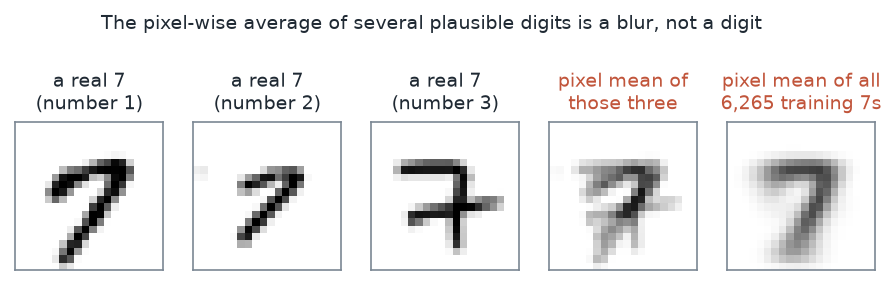

**Why an MSE-trained decoder blurs.** Several different images are plausible for one code and
class: the same 7 can be written with the bar a little higher or lower. The decoder cannot know
which, and the single output that minimises the *average squared error* over all of them is their
pixel-wise **mean**. Averaging strokes in slightly different places gives a grey smear, as the
figure shows on this dataset's own 7s. Nothing in the MSE term objects to that smear, because it
is the best guess under that loss.

**What a discriminator adds.** A discriminator is a second network trained to tell real images
from the decoder's output. Its judgement becomes a loss for the decoder: output that the
discriminator can spot as fake is penalised. A grey smear does not look like any real digit, so a
decoder that also has to fool the discriminator is pushed toward outputs that look like one
plausible digit, with crisp strokes, instead of the average of many (lecture 9, pp. 45-46).

That is the hypothesis this notebook tests:

> *Adding a discriminator term to the loss function of a cVAE during training increases the sharpness of the reconstructed images.*

It is the idea behind the **VAE-GAN** of Larsen et al. (2016), who reported sharper samples than a
plain VAE on faces. The price is known too: an output that commits to one plausible digit can be
further, pixel by pixel, from the particular digit it was asked to reconstruct, so pixel error can
rise while sharpness does. `main_report.ipynb` measures both.

## 5 The discriminator

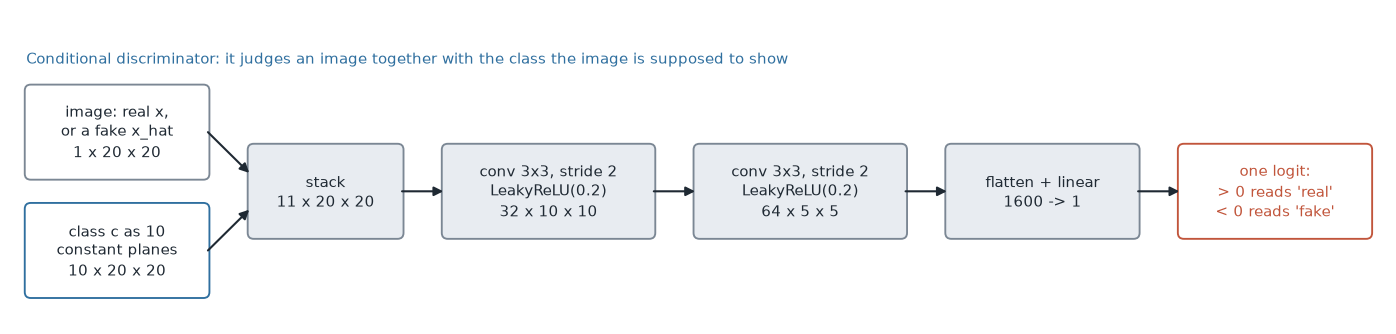

The discriminator judges an image *together with its class* (lecture 9, p39: in a conditional GAN
"the class is given to both" networks). A well-drawn 3 labelled "8" should read as fake. The class
enters as ten extra image planes, each filled with that class's one-hot value, so every convolution
sees it. The network is deliberately small, two convolutions and one linear layer. A discriminator
much stronger than the decoder wins at once, and a discriminator that always wins gives the decoder
no usable signal about *how* to improve.

| Call | What you give it | What you get back |
|---|---|---|
| `nn.LeakyReLU(0.2)` | any tensor | negative values multiplied by 0.2 instead of set to 0, so small gradients survive |
| `cond[:, :, None, None].expand(-1, -1, 20, 20)` | one-hot rows (batch, 10) | (batch, 10, 20, 20): each class value copied across a whole plane |

In [17]:
# The conditional discriminator. The class enters as ten constant image planes, so every
# convolution sees the image together with the class it is supposed to show.
class Discriminator(nn.Module):
    def __init__(self, num_classes=10, image_size=20):
        super().__init__()
        self.image_size = image_size
        self.net = nn.Sequential(
            # 11x20x20 -> 32x10x10: the image plus one plane per class
            nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # 32x10x10 -> 64x5x5
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # 1600 features -> one logit: above 0 reads "real", below 0 reads "fake"
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 1),
        )

    def forward(self, x, cond):
        planes = cond[:, :, None, None].expand(-1, -1, self.image_size, self.image_size)
        return self.net(torch.cat([x, planes], dim=1))

## 6 The adversarial losses

Lecture 9 p41 fixes the recipe: the loss is binary cross-entropy, "real images are '1', fake
images are '0'", and there are two optimisers. The brief's figure writes the same two losses:

$$\mathcal{L}_D = \mathbb{E}_x[\log(1 - D(x))] + \mathbb{E}_z[\log D(G(z))] \qquad \mathcal{L}_G = \mathbb{E}_z[\log(1 - D(G(z)))]$$

where D(.) is the probability of "real". The discriminator minimises the first, pushing D(x) up to 1
on real images and D(G(z)) down to 0 on fakes. (Slides 37 and 45 label the classes the other way
round; the formula and p41 agree with each other, and this notebook follows them.)

**The generator's loss is used in its non-saturating form**, `-log D(G(z))`, instead of the
figure's `log(1 - D(G(z)))`. Both are smallest when the discriminator is fooled. They differ early
in training, when fakes are poor and D(G(z)) is near 0: there `log(1 - D)` is almost flat, so its
gradient nearly vanishes exactly when the decoder most needs a signal, while `-log D` is steep.
Goodfellow et al. (2014, section 3) recommend the same swap. In code it is simply the cross-entropy
of a fake against the label 1.

**Two kinds of fake.** The decoder produces two kinds of image, and the discriminator sees both, each
with half the weight:

- **reconstructions** `decode(z, c)` with z from an image's own cloud: the objects the hypothesis
  is about;
- **samples** `decode(z_p, c)` with `z_p ~ N(0, I)`: what conditional generation, Task 3, produces.

The cVAE's total loss becomes `100 MSE + 0.1 KL + lambda * L_G`. `lambda` is the only new setting,
and section 9 chooses it.

| Call | What you give it | What you get back |
|---|---|---|
| `nn.BCEWithLogitsLoss()(logits, targets)` | raw scores and 0/1 labels | the mean binary cross-entropy, with the sigmoid applied inside for numerical stability |
| `torch.ones_like(t)`, `torch.zeros_like(t)` | a tensor | a tensor of 1s or 0s with its shape and device |

In [18]:
# Binary cross-entropy on logits, as lecture 9 p41 prescribes: real images carry the label 1
# and fakes the label 0. BCEWithLogitsLoss applies the sigmoid itself, which is more stable.
bce = nn.BCEWithLogitsLoss()


def discriminator_loss(discriminator, x_real, x_recon, x_prior, cond):
    """L_D. The two kinds of fake share the fake half of the loss equally."""
    real = discriminator(x_real, cond)
    fake_recon, fake_prior = discriminator(x_recon, cond), discriminator(x_prior, cond)
    loss_real = bce(real, torch.ones_like(real))
    loss_fake = (0.5 * bce(fake_recon, torch.zeros_like(fake_recon))
                 + 0.5 * bce(fake_prior, torch.zeros_like(fake_prior)))
    return loss_real + loss_fake


def generator_loss(discriminator, x_recon, x_prior, cond):
    """L_G, non-saturating: fakes are scored against the label 'real', so the loss is
    -log D(fake), whose gradient stays large while D is still rejecting fakes."""
    fake_recon, fake_prior = discriminator(x_recon, cond), discriminator(x_prior, cond)
    return (0.5 * bce(fake_recon, torch.ones_like(fake_recon))
            + 0.5 * bce(fake_prior, torch.ones_like(fake_prior)))

## 7 One training step

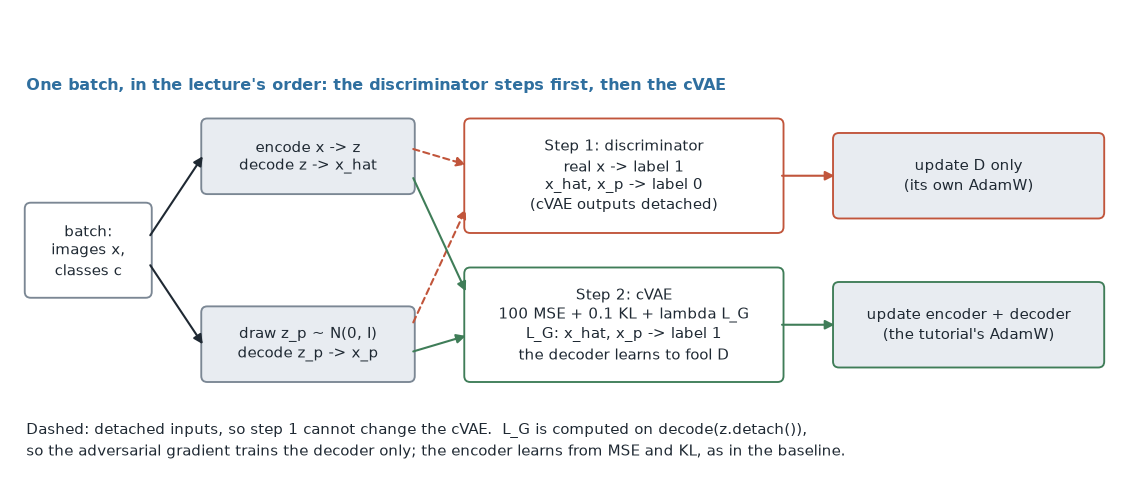

Each batch takes two steps, in the order of lecture 9 p41, **discriminator first**:

1. **Discriminator step.** Real images are scored against 1, reconstructions and samples against 0,
   and only the discriminator's weights move. The fakes are passed through `.detach()`, which cuts
   them off from the cVAE, so this step cannot change the cVAE.
2. **cVAE step.** The baseline's loss plus `lambda * L_G`, scored by the *updated* discriminator,
   and only the cVAE's weights move.

**The adversarial gradient reaches the decoder only.** `L_G` is computed on `decode(z.detach(), c)`:
the same image, but with the path back into the encoder cut. The encoder therefore learns from MSE
and KL exactly as in the baseline, and only the decoder is asked to fool the discriminator. This
follows Larsen et al. (2016), who keep the GAN error out of the encoder: the encoder's job is to
describe the input, and making its codes fool a discriminator would work against that.

Everything else (seed, batch order, epochs, architecture, optimiser, learning-rate schedule) is
identical to `cVAE_Baseline.ipynb`, so the discriminator term is the only difference between the
two models. The discriminator's own optimiser follows the same cosine schedule, so both players
slow down together and the contest ends settled rather than with one side still learning.

| Call | What you give it | What you get back |
|---|---|---|
| `t.detach()` | a tensor | the same values with no link back to the computation that made them |
| `torch.randn_like(mu)` | a tensor | standard normal noise of the same shape, on the same device |

In [19]:
# The tutorial's loop with a discriminator step placed before the cVAE step, the order of
# lecture 9 p41. Everything the baseline does is still here; the new lines are the D step,
# the prior samples, and lambda x L_G added to the cVAE's loss.
def training_loop_adversarial(model, discriminator, train_dataloader, dev_dataloader,
                              nb_epoch, lam):
    optimizer = vae_optimizer(model.parameters())
    d_optimizer = optim.AdamW(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    # Both players follow the same schedule, so the contest slows down together
    scheduler = cosine_schedule(optimizer, nb_epoch)
    d_scheduler = cosine_schedule(d_optimizer, nb_epoch)
    history = new_history(adversarial=True)
    for epoch in range(nb_epoch):
        started = time.perf_counter()
        model.train()
        discriminator.train()
        totals, count = np.zeros(5), 0
        for batch in train_dataloader:
            x, cond = get_batch(batch, device, f_train=True)
            # The cVAE's forward pass, written out so z is available: z = mu + sigma * eps
            mu, logvar = model.encode(x, cond)
            z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
            x_hat = model.decode(z, cond)
            x_prior = model.decode(torch.randn_like(mu), cond)
            # Step 1, the discriminator. Detached fakes: this step cannot change the cVAE
            d_optimizer.zero_grad()
            d_loss = discriminator_loss(discriminator, x, x_hat.detach(), x_prior.detach(), cond)
            d_loss.backward()
            d_optimizer.step()
            # Step 2, the cVAE. L_G sees decode(z.detach()): its gradient reaches the decoder only
            optimizer.zero_grad()
            total_loss, recon_loss, kl_loss = compute_loss(x, x_hat, mu, logvar)
            g_loss = generator_loss(discriminator, model.decode(z.detach(), cond), x_prior, cond)
            (total_loss + lam * g_loss).backward()
            optimizer.step()
            totals += len(x) * np.array([total_loss.item(), recon_loss.item(), kl_loss.item(),
                                         d_loss.item(), g_loss.item()])
            count += len(x)
        record(history, "train", totals[:3] / count)
        history["train_d_loss"].append(float(totals[3] / count))
        history["train_g_loss"].append(float(totals[4] / count))
        if dev_dataloader is not None:
            record(history, "dev", evaluate_loss(model, dev_dataloader))
            history["dev_d_accuracy"].append(
                discriminator_accuracy(model, discriminator, dev_dataloader))
        history["seconds"].append(time.perf_counter() - started)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        scheduler.step()
        d_scheduler.step()
        report_epoch(epoch, nb_epoch, history)
    return history

### 7.1 The discriminator's size, and its accuracy

The discriminator's size, and one pass on a batch. `discriminator_accuracy` is the monitor used
during training: how often the discriminator calls development images, and the fakes made
from them, correctly, with real and fake weighted equally.

In [20]:
# The discriminator's size, and one pass on a development batch: one logit per image.
discriminator = Discriminator(NUM_CLASSES).to(device)
x, cond = get_batch(next(iter(dev_dataloader)), device)
print(f"discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")
print(f"D(x, c) for a batch of {len(x)}: {tuple(discriminator(x, cond).shape)}")

discriminator parameters: 23,297
D(x, c) for a batch of 1000: (1000, 1)


In [21]:
# How often the discriminator is right on development images: real ones should score above 0,
# their reconstructions and fresh samples below. The two halves are averaged, so 0.5 means it
# is fooled and 1.0 means it wins outright, when its gradient says little about how to improve.
def discriminator_accuracy(model, discriminator, dataloader, seed=SEED):
    model.eval()
    discriminator.eval()
    noise = torch.Generator().manual_seed(seed)
    real_right, fake_right, count = 0, 0, 0
    with torch.no_grad():
        for batch in dataloader:
            x, cond = get_batch(batch, device, f_train=False)
            mu, _ = model.encode(x, cond)
            x_prior = model.decode(torch.randn(len(x), Z_DIM, generator=noise).to(device), cond)
            real_right += (discriminator(x, cond) > 0).sum().item()
            fake_right += (discriminator(model.decode(mu, cond), cond) < 0).sum().item()
            fake_right += (discriminator(x_prior, cond) < 0).sum().item()
            count += len(x)
    return 0.5 * real_right / count + 0.5 * fake_right / (2 * count)

## 8 Measuring sharpness

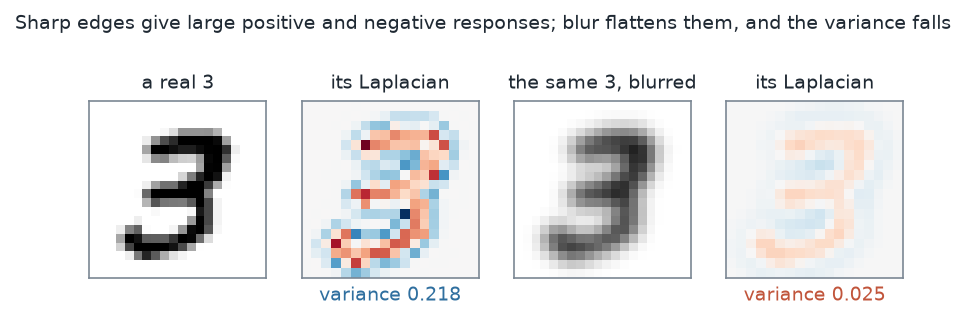

The **Laplacian** of an image measures how sharply brightness bends at each pixel: the 3 x 3 kernel
`[[0, 1, 0], [1, -4, 1], [0, 1, 0]]` compares each pixel with its four neighbours. At a crisp stroke
edge the response swings strongly positive and negative, and in a smooth blur it stays near zero. The
**variance** of the response over the image is therefore one number that is high for a sharp image
and low for a blurred one (Pech-Pacheco et al., 2000), and the brief names it. Because the kernel's
weights sum to zero, flipping black and white only flips the response's sign, so the variance is the
same for this inverted data as for ordinary MNIST.

It has one known weakness: noise and ringing also raise it. So a reconstruction is compared with the
**real images' own value**, and above that level higher is not better. A second measure, the
**mid-grey fraction**, counts pixels that are neither background nor stroke (between 0.1 and 0.9).
Blur raises it, and so does noise, the opposite direction to the Laplacian's error, so the two
agreeing is stronger evidence than either alone.

| Call | What you give it | What you get back |
|---|---|---|
| `F.conv2d(images, kernel)` | images (n, 1, 20, 20) and a (1, 1, 3, 3) kernel | the 18 x 18 response of each image (no padding) |
| `t.flatten(1).var(dim=1)` | (n, 1, 18, 18) | the variance within each image |

In [22]:
# Sharpness as the variance of the Laplacian (Pech-Pacheco et al., 2000). The 3x3 kernel
# responds to curvature in brightness: large at a crisp edge, near zero in a smooth blur.
LAPLACE_WEIGHTS = [[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]]
LAPLACE_KERNEL = torch.tensor(LAPLACE_WEIGHTS, device=device).view(1, 1, 3, 3)


def laplacian_variance(images, batch_size=2000):
    """Per-image variance of the Laplacian response (valid convolution, 18 x 18 values)."""
    values = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            response = F.conv2d(images[start:start + batch_size].to(device), LAPLACE_KERNEL)
            values.append(response.flatten(1).var(dim=1).cpu())
    return torch.cat(values).double().numpy()


# A second view of blur: the share of pixels that are neither background nor stroke.
MID_GREY = (0.1, 0.9)


def midgrey_fraction(images):
    grey = (images > MID_GREY[0]) & (images < MID_GREY[1])
    return grey.flatten(1).float().mean(dim=1).double().numpy()

The development images' own sharpness, the reference every reconstruction is compared with.

In [23]:
# The development split's own sharpness is the reference a reconstruction is compared with.
dev_images, dev_labels = train_images[dev_index], train_labels[dev_index]
real_dev_sharpness = laplacian_variance(dev_images).mean()
real_dev_midgrey = midgrey_fraction(dev_images).mean()
print(f"development images: Laplacian variance {real_dev_sharpness:.4f}, "
      f"mid-grey fraction {real_dev_midgrey:.4f}")

development images: Laplacian variance 0.2311, mid-grey fraction 0.1451


## 9 Choosing lambda on the development split

`lambda` sets how much the decoder cares about fooling the discriminator against matching pixels.
Too small and nothing changes; too large and the decoder may chase the discriminator at the cost of
the digit. Four values are tried, each with a full development run on the fit split and the same
seed. The rule for choosing, fixed before the runs:

1. set aside any run whose discriminator won outright, accuracy above 0.98 on the development split
   over the last 10 epochs, because its gradient no longer carries information (if every run
   is set aside, keep the one with the lowest accuracy);
2. of the rest, choose the lambda whose development reconstructions come **closest to the real
   development images' sharpness**, the hypothesis's own quantity;
3. break a tie toward the smaller lambda.

The test split plays no part: the choice uses the development split only.

In [24]:
# Checkpoints are saved from the CPU, so they load on a machine without a GPU.
def cpu_state(module):
    return {name: tensor.detach().cpu().clone() for name, tensor in module.state_dict().items()}

In [25]:
# One development run per lambda on the fit split, with everything else held fixed.
LAMBDAS = (0.03, 0.1, 0.3, 1.0)
z_preview = torch.randn(4, Z_DIM, generator=torch.Generator().manual_seed(SEED)).to(device)
sweep, sweep_histories, previews = [], {}, {}
for lam in LAMBDAS:
    print(f"--- lambda = {lam}")
    _ = torch.manual_seed(SEED)
    model = cVAE(Z_DIM, num_classes=NUM_CLASSES).to(device)
    discriminator = Discriminator(NUM_CLASSES).to(device)
    history = training_loop_adversarial(model, discriminator, fit_dataloader, dev_dataloader,
                                        EPOCHS, lam)
    rebuilt = reconstruct(model, dev_images, dev_labels)
    sweep.append({"lambda": lam, "dev_recon_loss": float(np.mean(history["dev_recon"][-WINDOW:])),
                  "dev_sharpness": float(laplacian_variance(rebuilt).mean()),
                  "real_dev_sharpness": float(real_dev_sharpness),
                  "d_accuracy": float(np.mean(history["dev_d_accuracy"][-WINDOW:]))})
    sweep_histories[str(lam)] = history
    previews[lam] = sample_grid(model, z_preview)[0]

--- lambda = 0.03


epoch   1/150  train loss 12.1909  dev recon 6.1197  D accuracy 0.797  (4.8 s)


epoch  10/150  train loss 3.2622  dev recon 2.5477  D accuracy 0.942  (4.8 s)


epoch  20/150  train loss 2.8233  dev recon 1.9546  D accuracy 0.907  (4.8 s)


epoch  30/150  train loss 2.6183  dev recon 1.6884  D accuracy 0.893  (4.7 s)


...

epoch 110/150  train loss 2.4352  dev recon 1.2378  D accuracy 0.595  (4.8 s)


epoch 120/150  train loss 2.4277  dev recon 1.2298  D accuracy 0.603  (4.8 s)


epoch 130/150  train loss 2.4221  dev recon 1.2274  D accuracy 0.599  (4.8 s)


epoch 140/150  train loss 2.4186  dev recon 1.2229  D accuracy 0.601  (4.6 s)


epoch 150/150  train loss 2.4177  dev recon 1.2232  D accuracy 0.599  (4.6 s)


### 9.1 The choice

The sweep's summary and the chosen value. It is written to the history file, and
`main_report.ipynb` reads it from there.

In [26]:
# The selection rule, fixed before the sweep ran. Runs whose discriminator won outright are
# set aside; of the rest, the reconstructions closest to real sharpness win, and a tie goes
# to the smaller lambda.
print("lambda   dev recon loss   dev sharpness   real dev sharpness   D accuracy")
for row in sweep:
    print(f"{row['lambda']:<8} {row['dev_recon_loss']:>14.4f} {row['dev_sharpness']:>15.4f} "
          f"{row['real_dev_sharpness']:>20.4f} {row['d_accuracy']:>12.4f}")
eligible = [row for row in sweep if row["d_accuracy"] <= 0.98]
if not eligible:
    eligible = [min(sweep, key=lambda row: row["d_accuracy"])]
chosen = min(eligible, key=lambda row: (abs(row["dev_sharpness"] - row["real_dev_sharpness"]),
                                        row["lambda"]))
LAMBDA = chosen["lambda"]
print(f"\nchosen lambda: {LAMBDA}")

lambda   dev recon loss   dev sharpness   real dev sharpness   D accuracy
0.03             1.1835          0.1466               0.2311       0.8749
0.1              1.1954          0.1732               0.2311       0.7299
0.3              1.2427          0.1909               0.2311       0.6331
1.0              1.2233          0.1857               0.2311       0.5997

chosen lambda: 0.3


### 9.2 What each lambda produces

Four latent codes decoded under every class by each development model (digits as rows). The chosen
lambda's title is in colour.

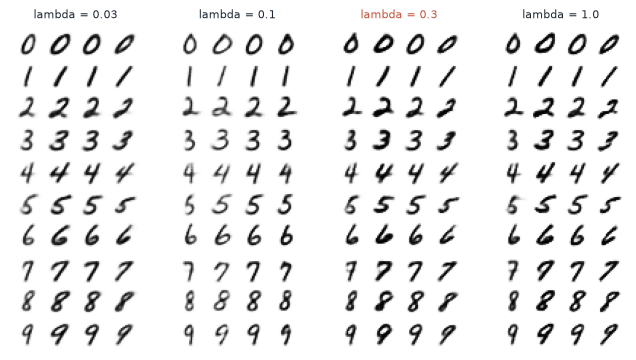

In [27]:
# Four latent codes decoded under every class, for each lambda: what the choice looks like.
fig, axes = plt.subplots(1, len(LAMBDAS), figsize=(2.0 * len(LAMBDAS), 4.2))
for ax, lam in zip(np.atleast_1d(axes), LAMBDAS):
    ax.imshow(make_grid(previews[lam], nrow=4, pad_value=1)[0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"lambda = {lam}", color=WARM if lam == LAMBDA else INK)
    ax.axis("off")
plt.show()

## 10 Convergence of the chosen run

The chosen development run's reconstruction loss, which has to settle, and the discriminator's
accuracy, which should stay away from 0.5 (no better than guessing) and from 1 (winning
outright).

dev reconstruction loss, mean of the last 10 epochs : 1.2427
mean of the 10 epochs before              : 1.2442
relative change -0.0012, within 1%: True


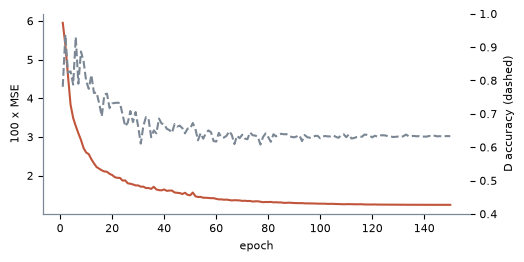

In [28]:
# The chosen run's development curves, and its convergence statistic. The reconstruction
# loss is what has to settle; the discriminator's accuracy shows whether the contest stayed
# open, away from both 0.5 and 1.
dev_history = sweep_histories[str(LAMBDA)]
dev_convergence = convergence(dev_history["dev_recon"], WINDOW)
print(f"dev reconstruction loss, mean of the last {WINDOW} epochs : "
      f"{dev_convergence['last_mean']:.4f}")
print(f"mean of the {WINDOW} epochs before              : {dev_convergence['previous_mean']:.4f}")
print(f"relative change {dev_convergence['relative_change']:+.4f}, "
      f"within 1%: {dev_convergence['within_1pct']}")
epochs = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(figsize=(5.5, 2.6))
ax.plot(epochs, dev_history["dev_recon"], color=WARM, label="dev reconstruction loss")
ax.set_xlabel("epoch")
ax.set_ylabel("100 x MSE")
twin = ax.twinx()
twin.plot(epochs, dev_history["dev_d_accuracy"], color=MUTED, linestyle="--")
twin.set_ylabel("D accuracy (dashed)")
twin.set_ylim(0.4, 1.0)
plt.show()

## 11 The final models

As for the baseline: lambda fixed, retrained on all training images, once per seed 0, 1 and 2, with
the same batch orders the baseline's final models used.

In [29]:
# The final models: lambda fixed, retrained on all N_TOTAL images once per seed, with the
# same seeds and batch orders as the baseline's final models.
refit_loaders = {seed: make_loader(order, shuffle=True, seed=seed) for seed in SEEDS}
checkpoint, refit_histories = {}, {}
for seed in SEEDS:
    print(f"--- seed {seed}")
    _ = torch.manual_seed(seed)
    model = cVAE(Z_DIM, num_classes=NUM_CLASSES).to(device)
    discriminator = Discriminator(NUM_CLASSES).to(device)
    refit_histories[str(seed)] = training_loop_adversarial(model, discriminator,
                                                           refit_loaders[seed], None, EPOCHS,
                                                           LAMBDA)
    checkpoint[f"seed_{seed}"] = cpu_state(model)
    checkpoint[f"discriminator_seed_{seed}"] = cpu_state(discriminator)

--- seed 0


epoch   1/150  train loss 11.1505  (5.3 s)


epoch  10/150  train loss 3.2749  (5.5 s)


epoch  20/150  train loss 2.9023  (5.3 s)


epoch  30/150  train loss 2.7090  (5.5 s)


...

epoch 110/150  train loss 2.3673  (5.3 s)


epoch 120/150  train loss 2.3560  (5.4 s)


epoch 130/150  train loss 2.3504  (5.4 s)


epoch 140/150  train loss 2.3490  (5.3 s)


epoch 150/150  train loss 2.3474  (5.4 s)


### 11.1 Sanity check and saving

The same bar as the baseline's: each seed's final reconstruction loss must be well below that of a
model that answers every input with the mean image. Then the weights and the curves are saved.

In [30]:
# Every final model must beat the trivial predictor that answers every image with the mean
# training image. Its loss, 100 x MSE, is the bar each seed's last epoch has to clear.
refit_images = train_images[order]
mean_image = refit_images.mean(dim=0, keepdim=True)
trivial_loss = 100 * F.mse_loss(mean_image.expand_as(refit_images), refit_images).item()
print(f"trivial predictor (mean image): {trivial_loss:.4f}")
for seed, history in refit_histories.items():
    print(f"seed {seed}: last-epoch reconstruction loss {history['train_recon'][-1]:.4f}")
    assert history["train_recon"][-1] < trivial_loss, f"seed {seed} did not learn"

trivial predictor (mean image): 5.6878
seed 0: last-epoch reconstruction loss 1.4735
seed 1: last-epoch reconstruction loss 1.6165
seed 2: last-epoch reconstruction loss 1.4701


In [31]:
# The weights (the cVAE and its discriminator, one pair per seed) and every curve, including
# the whole lambda sweep. main_report.ipynb reads both files.
torch.save(checkpoint, "cVAE_DiscriminatorLoss.pth")
history_record = {
    "model": "cVAE_DiscriminatorLoss", "lambda": LAMBDA, "epochs": EPOCHS, "seeds": list(SEEDS),
    "window": WINDOW, "n_fit": len(fit_index), "n_dev": len(dev_index), "n_refit": len(order),
    "dev": dev_history, "convergence": dev_convergence, "refit": refit_histories,
    "sweep": sweep, "sweep_histories": sweep_histories,
    "seconds_per_epoch": float(np.mean([np.mean(h["seconds"]) for h in refit_histories.values()])),
    "device": str(device)}
with open("cVAE_DiscriminatorLoss_history.json", "w") as handle:
    json.dump(history_record, handle)
print(f"saved cVAE_DiscriminatorLoss.pth ({', '.join(checkpoint)})")
print("saved cVAE_DiscriminatorLoss_history.json")

saved cVAE_DiscriminatorLoss.pth (seed_0, discriminator_seed_0, seed_1, discriminator_seed_1, seed_2, discriminator_seed_2)
saved cVAE_DiscriminatorLoss_history.json


## 12 Samples

The same first look as in the baseline notebook, from the same 12 codes: rows are digits, and each
column is one code decoded under all ten classes. The side-by-side comparison, and every
measurement, is in `main_report.ipynb`.

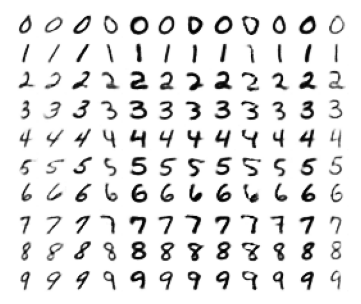

In [32]:
# A first look at conditional sampling from the seed-0 model: rows are the digits 0 to 9 and
# each column is one latent code from N(0, I), decoded under every class.
_ = model.load_state_dict(checkpoint["seed_0"])
z_grid = torch.randn(12, Z_DIM, generator=torch.Generator().manual_seed(SEED)).to(device)
images, _ = sample_grid(model, z_grid)
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.imshow(make_grid(images, nrow=12, pad_value=1)[0], cmap="gray", vmin=0, vmax=1)
ax.axis("off")
plt.show()